# CSE252 – Unit III Practicals
## Practical 6–10: Introduction to Supervised Machine Learning

**Level:** Beginner / Introduction to Machine Learning

In these practicals, we will use **real datasets available in scikit-learn** instead of manually created/dummy data.

| Practical | Topic | Dataset |
|---|---|---|
| 6 | Linear Regression | Diabetes Dataset |
| 7 | Logistic Regression | Breast Cancer Dataset |
| 8 | K-Nearest Neighbour | Iris Dataset |
| 9 | Decision Tree & Random Forest | Iris Dataset |
| 10 | Bias, Variance, Underfitting & Overfitting | Diabetes Dataset |

### Common Machine Learning Workflow

**Dataset → Features (X) → Target (y) → Train/Test Split → Model → Prediction → Evaluation → Visualization**


## Common Libraries

We will use datasets that are already available in `scikit-learn`, so students do not need to download CSV files.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully!")

Libraries imported successfully!


# Practical 6 – Implementation of Linear Regression

### Objective
To implement **Linear Regression** using a real dataset and understand how a model predicts a numerical value.

### Dataset: Diabetes Dataset
The Diabetes dataset contains information about patients and a numerical disease-progression target.

For easy visualization, we will use **BMI** as one feature to predict the disease progression value.

**Important:** This is a real dataset provided by scikit-learn, not manually created data.

In [2]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Step 1 – Understand the data

We will use:

- **X:** BMI
- **y:** Disease progression value

The target is numerical, so this is a **Regression** problem.

In [3]:
X = df[["bmi"]]
y = df["target"]

print("Number of rows:", len(df))
print("Feature:", X.columns[0])
print("Target:", "target")

Number of rows: 442
Feature: bmi
Target: target


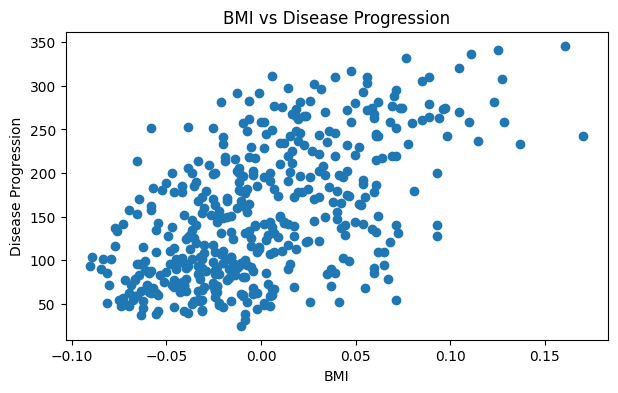

In [4]:
plt.figure(figsize=(7, 4))
plt.scatter(X, y)
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("BMI vs Disease Progression")
plt.show()

### Step 2 – Split the data

We keep some data for testing so that we can check how well the model works on **unseen data**.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 353
Testing samples: 89


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Model trained successfully!
Slope: 998.5776891375598
Intercept: 152.00335421448167


### Step 3 – Make predictions

In [7]:
y_pred = model.predict(X_test)

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
0,219.0,145.806227
1,70.0,188.857390
2,202.0,147.958785
3,230.0,203.925298
4,111.0,131.814599
5,84.0,127.509482
6,242.0,322.315998
7,272.0,197.467623
8,94.0,61.856458
9,96.0,167.331809


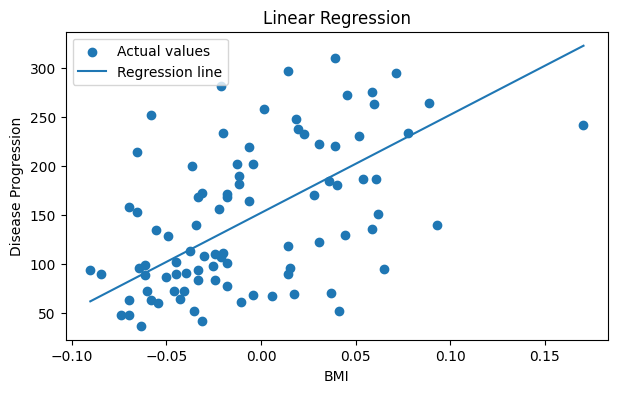

In [8]:
plt.figure(figsize=(7, 4))
plt.scatter(X_test, y_test, label="Actual values")

# Sort values so the regression line is displayed clearly
order = np.argsort(X_test["bmi"].values)
plt.plot(
    X_test["bmi"].values[order],
    y_pred[order],
    label="Regression line"
)

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Linear Regression")
plt.legend()
plt.show()

### Step 4 – Evaluate the model

- **MAE:** Average absolute prediction error. Lower is better.
- **MSE:** Gives more penalty to large errors. Lower is better.
- **R²:** Shows how much variation in the target is explained by the model. Higher is generally better.

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("R²  :", round(r2, 2))

MAE : 52.26
MSE : 4061.83
R²  : 0.23


### Key Idea

**Linear Regression predicts a numerical value.**

Example in this practical:

**BMI → Predicted Disease Progression**

The model tries to draw the best-fitting straight line through the data.

# Practical 7 – Implementation of Logistic Regression

### Objective
To implement **Logistic Regression** for binary classification using a real dataset.

### Dataset: Breast Cancer Dataset

The dataset contains measurements calculated from breast cancer cell images.

The target has two classes:

- **0 = Malignant**
- **1 = Benign**

For easy understanding and visualization, we will use **mean radius** as the input feature.

In [10]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
cancer_df = cancer.frame

cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [11]:
X = cancer_df[["mean radius"]]
y = cancer_df["target"]

print("Feature:", X.columns[0])
print("Target classes:")
print(cancer.target_names)

Feature: mean radius
Target classes:
['malignant' 'benign']


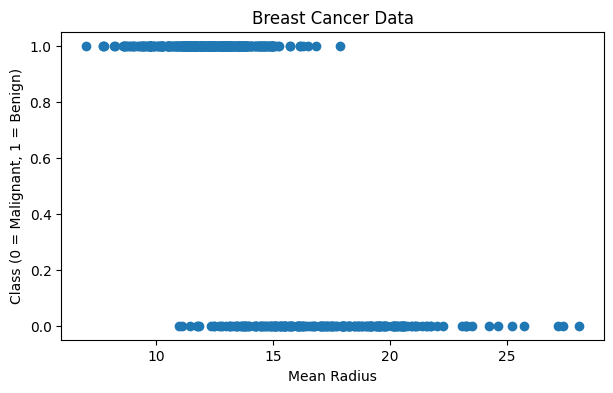

In [12]:
plt.figure(figsize=(7, 4))
plt.scatter(X, y)
plt.xlabel("Mean Radius")
plt.ylabel("Class (0 = Malignant, 1 = Benign)")
plt.title("Breast Cancer Data")
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model trained successfully!")

Model trained successfully!


In [14]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability of Benign": y_prob
})

result.head(10)

,Actual,Predicted,Probability of Benign
0,0,0,0.006074
1,1,1,0.975780
2,0,1,0.708205
3,1,0,0.128727
4,0,0,0.000748
5,1,1,0.827146
6,1,1,0.997643
7,0,0,0.005307
8,0,0,0.021826
9,0,0,0.002037


Accuracy: 0.86


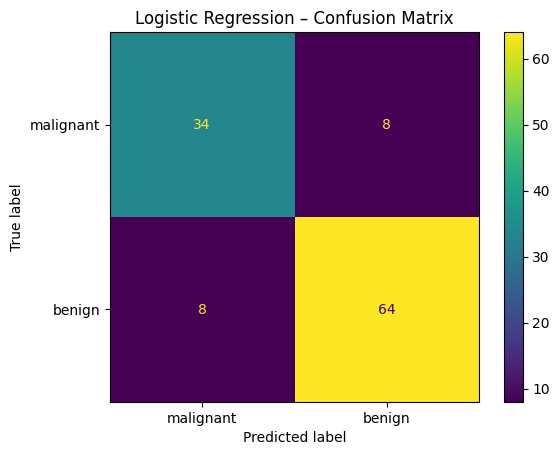

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 2))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names
)
disp.plot()
plt.title("Logistic Regression – Confusion Matrix")
plt.show()

### Understanding Logistic Regression

Logistic Regression predicts a **probability between 0 and 1**.

A threshold is then used to decide the class.

For example:

- Probability ≥ 0.5 → Class 1
- Probability < 0.5 → Class 0

### Key Idea

**Logistic Regression is used for classification, not ordinary numerical prediction.**

# Practical 8 – Classification using K-Nearest Neighbour (KNN)

### Objective
To implement **K-Nearest Neighbour (KNN)** using the Iris dataset.

### Dataset: Iris Dataset

The Iris dataset contains measurements of iris flowers.

It has three classes:

- Setosa
- Versicolor
- Virginica

We will use **sepal length** and **sepal width** so that students can visualize the data.

In [16]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris_df = iris.frame

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


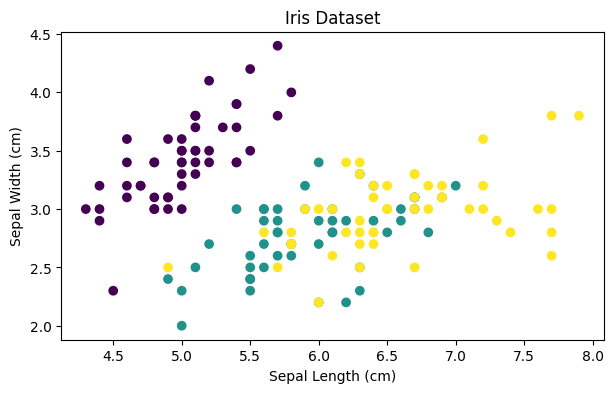

In [17]:
X = iris_df[["sepal length (cm)", "sepal width (cm)"]]
y = iris_df["target"]

plt.figure(figsize=(7, 4))
plt.scatter(
    X["sepal length (cm)"],
    X["sepal width (cm)"],
    c=y
)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Iris Dataset")
plt.show()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))

Accuracy: 0.67


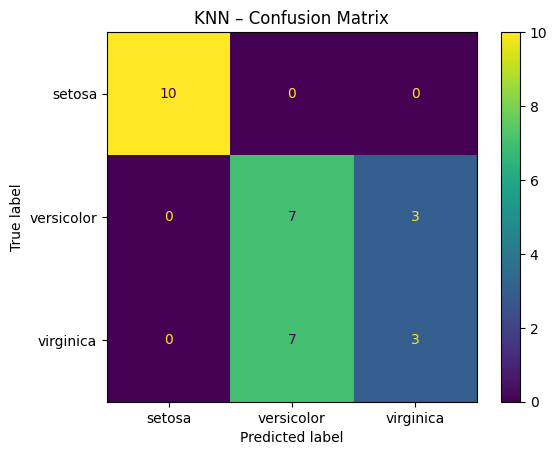

In [19]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)
disp.plot()
plt.title("KNN – Confusion Matrix")
plt.show()

### Try Different Values of K

K tells the model how many nearby training examples to look at.

- Small K → model pays more attention to nearby points.
- Larger K → model considers more neighbours.

In [20]:
k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred))

pd.DataFrame({
    "K": k_values,
    "Accuracy": accuracies
})

,K,Accuracy
0,1,0.600000
1,3,0.666667
2,5,0.766667
3,7,0.766667
4,9,0.800000


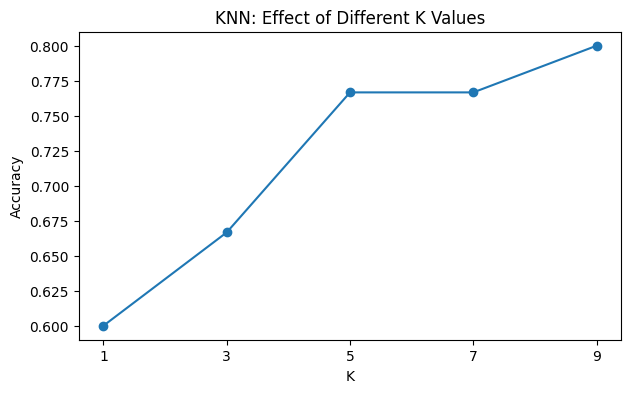

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN: Effect of Different K Values")
plt.xticks(k_values)
plt.show()

### Key Idea

KNN classifies a new data point by looking at its **nearest examples**.

**New point → Find nearest neighbours → Majority class → Prediction**

# Practical 9 – Classification using Decision Tree and Random Forest

### Objective
To implement **Decision Tree** and **Random Forest** classification using the Iris dataset.

Both models will use the same dataset so that students can easily compare them.

In [22]:
# Use all four Iris features
X = iris_df.drop(columns=["target"])
y = iris_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


## A. Decision Tree

A Decision Tree makes decisions using simple rules.

For example:

**If feature < value → go left**

**Otherwise → go right**

In [23]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

print("Decision Tree Accuracy:",
      round(accuracy_score(y_test, tree_pred), 2))

Decision Tree Accuracy: 0.97


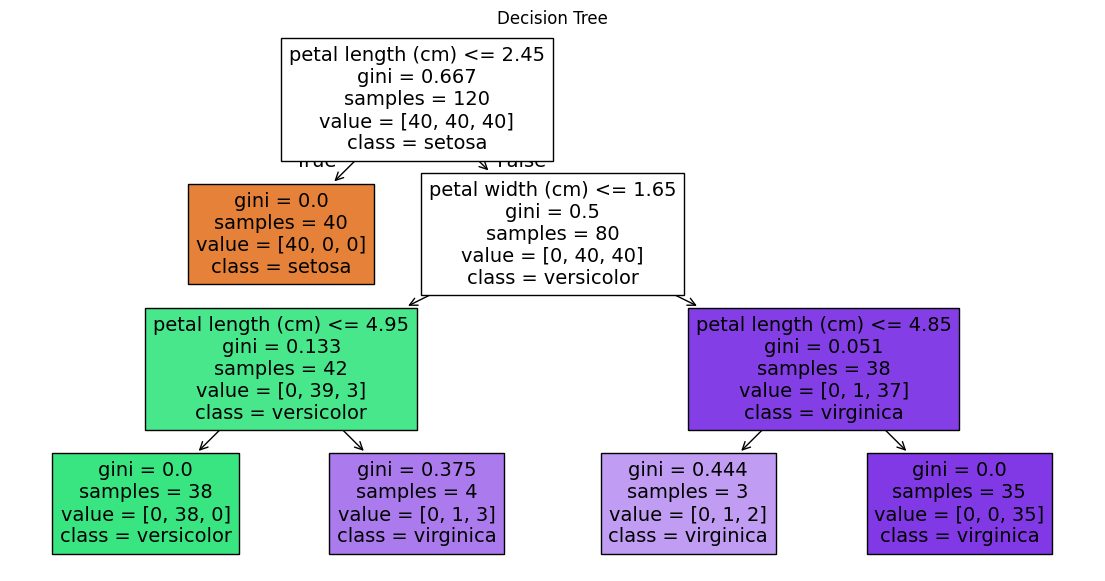

In [24]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 7))
plot_tree(
    tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.title("Decision Tree")
plt.show()

## B. Random Forest

A Random Forest combines predictions from **many Decision Trees**.

Instead of depending on one tree, it uses several trees and combines their results.

In [25]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

forest.fit(X_train, y_train)
forest_pred = forest.predict(X_test)

print("Random Forest Accuracy:",
      round(accuracy_score(y_test, forest_pred), 2))

Random Forest Accuracy: 0.97


In [26]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, forest_pred)
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.966667
1,Random Forest,0.966667


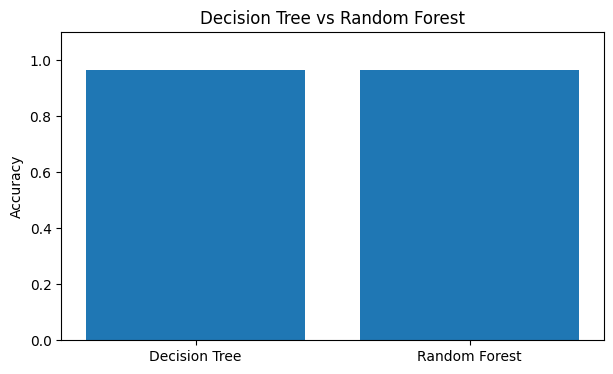

In [27]:
plt.figure(figsize=(7, 4))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Decision Tree vs Random Forest")
plt.ylim(0, 1.1)
plt.show()

### Key Idea

| Model | Simple Understanding |
|---|---|
| Decision Tree | One tree makes the decision |
| Random Forest | Many trees work together |

Random Forest is generally more robust than relying on a single Decision Tree.

# Practical 10 – Bias, Variance, Underfitting and Overfitting

### Objective
To understand how model complexity affects learning.

We will use the **real Diabetes dataset** again, but this time use multiple features to predict the numerical target.

We will compare models of different complexity.

In [28]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Use one real feature from the Diabetes dataset
X = df[["bmi"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

degrees = [1, 2, 5, 10]
train_errors = []
test_errors = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

pd.DataFrame({
    "Polynomial Degree": degrees,
    "Training MSE": train_errors,
    "Testing MSE": test_errors
})

,Polynomial Degree,Training MSE,Testing MSE
0,1,3854.112652,4061.825928
1,2,3849.333133,4085.025481
2,5,3823.763813,4085.845567
3,10,3724.612687,4315.533060


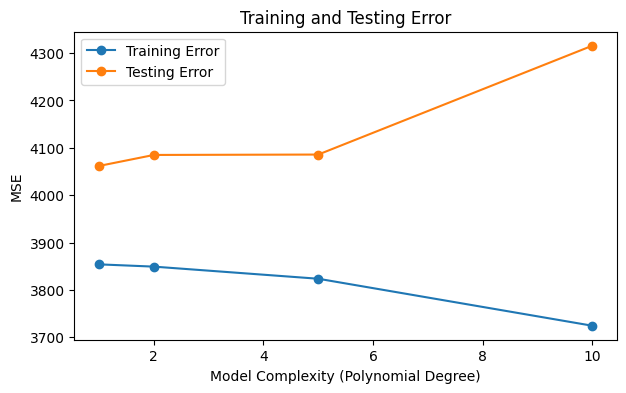

In [29]:
plt.figure(figsize=(7, 4))
plt.plot(degrees, train_errors, marker="o", label="Training Error")
plt.plot(degrees, test_errors, marker="o", label="Testing Error")
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("MSE")
plt.title("Training and Testing Error")
plt.legend()
plt.show()

### Understanding the concepts

**Underfitting**
- Model is too simple.
- It cannot capture the pattern properly.
- Usually associated with **high bias**.

**Good Fit**
- Model captures the important pattern.
- It performs reasonably well on new data.

**Overfitting**
- Model becomes too complex.
- It learns the training data too closely.
- It may perform poorly on new data.
- Usually associated with **high variance**.

### Simple way to remember

**High Bias → Too Simple → Underfitting**

**High Variance → Too Sensitive/Complex → Overfitting**

# Final Summary

| Practical | Topic | Dataset | Main Idea |
|---|---|---|---|
| 6 | Linear Regression | Diabetes | Predict a numerical value |
| 7 | Logistic Regression | Breast Cancer | Predict a class/probability |
| 8 | KNN | Iris | Classify using nearby examples |
| 9 | Decision Tree | Iris | Classify using decision rules |
| 9 | Random Forest | Iris | Combine many decision trees |
| 10 | Bias & Variance | Diabetes | Understand model complexity |

## Common Workflow

**1. Load Dataset**

↓  

**2. Select Features (X) and Target (y)**

↓

**3. Split into Training and Testing Data**

↓

**4. Create the Model**

↓

**5. Train the Model**

↓

**6. Make Predictions**

↓

**7. Evaluate the Model**

↓

**8. Visualize and Interpret the Result**

### Suggested Student Exercises

1. Linear Regression → Try another feature from the Diabetes dataset.
2. Logistic Regression → Try using two features from the Breast Cancer dataset.
3. KNN → Try K = 1, 3, 5, 7, 9.
4. Decision Tree → Change `max_depth`.
5. Random Forest → Change `n_estimators`.
6. Bias/Variance → Try different polynomial degrees.

**All datasets used in these practicals are real datasets available directly through scikit-learn.**